# Exploratory Data Analysis

Feature-level EDA on the **training** data only (leakage prevention).
Reuses the exact same data-preparation path as training via
`prepare_data`, so the split, augmentation, and processing are identical
to what the model sees.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cheatdetect.config import EDA_DIR, ExperimentConfig
from cheatdetect.data import (
    classify_correlation_pair,
    clean_features,
    detect_zero_variance,
    feature_summary,
    find_correlated_pairs,
)
from cheatdetect.pipeline import prepare_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

config = ExperimentConfig()

In [3]:
# ============================================================
# Prepare data (shared with training for reproducibility)
# ============================================================
data = prepare_data(config)

df_train_normal = data["df_train_normal"]
df_val_normal = data["df_val_normal"]
df_val_mixed = data["df_val_mixed"]
df_test_mixed = data["df_test_mixed"]

In [4]:
# ============================================================
# Dataset Summary
# ============================================================
summary_data = {
    "Train Normal": {
        "chunks": len(df_train_normal),
        "cheat": int(df_train_normal["is_cheating"].sum()),
        "sessions": df_train_normal["session_name"].nunique(),
    },
    "Val Normal": {
        "chunks": len(df_val_normal),
        "cheat": int(df_val_normal["is_cheating"].sum()),
        "sessions": df_val_normal["session_name"].nunique(),
    },
    "Val Mixed": {
        "chunks": len(df_val_mixed),
        "cheat": int(df_val_mixed["is_cheating"].sum()),
        "sessions": df_val_mixed["session_name"].nunique(),
    },
    "Test Mixed (LOCKED)": {
        "chunks": len(df_test_mixed),
        "cheat": int(df_test_mixed["is_cheating"].sum()),
        "sessions": df_test_mixed["session_name"].nunique(),
    },
}

df_summary = pd.DataFrame(summary_data).T
df_summary["normal"] = df_summary["chunks"] - df_summary["cheat"]
df_summary["cheat_pct"] = (df_summary["cheat"] / df_summary["chunks"] * 100).round(1)
df_summary

,chunks,cheat,sessions,normal,cheat_pct
Train Normal,1986,0,1339,1986,0.0
Val Normal,197,0,4,197,0.0
Val Mixed,196,82,5,114,41.8
Test Mixed (LOCKED),366,205,10,161,56.0


In [5]:
# ============================================================
# Zero-Variance Feature Detection (Train Normal Only)
# ============================================================
X_train_raw, feature_names_raw = clean_features(df_train_normal)
features_to_drop_zero_var = detect_zero_variance(X_train_raw)

print("=== Zero-Variance Features (variance == 0) ===")
if features_to_drop_zero_var:
    print(f"Found {len(features_to_drop_zero_var)} zero-variance features:")
    for feat in features_to_drop_zero_var:
        print(f"  - {feat}")
else:
    print("No zero-variance features found.")

print(f"\nTotal features before filtering: {len(feature_names_raw)}")

X_train_viz = X_train_raw.drop(columns=features_to_drop_zero_var, errors="ignore")
feature_names_viz = [f for f in feature_names_raw if f not in features_to_drop_zero_var]

print(f"Features for visualization: {len(feature_names_viz)}")

=== Zero-Variance Features (variance == 0) ===
No zero-variance features found.

Total features before filtering: 32
Features for visualization: 32


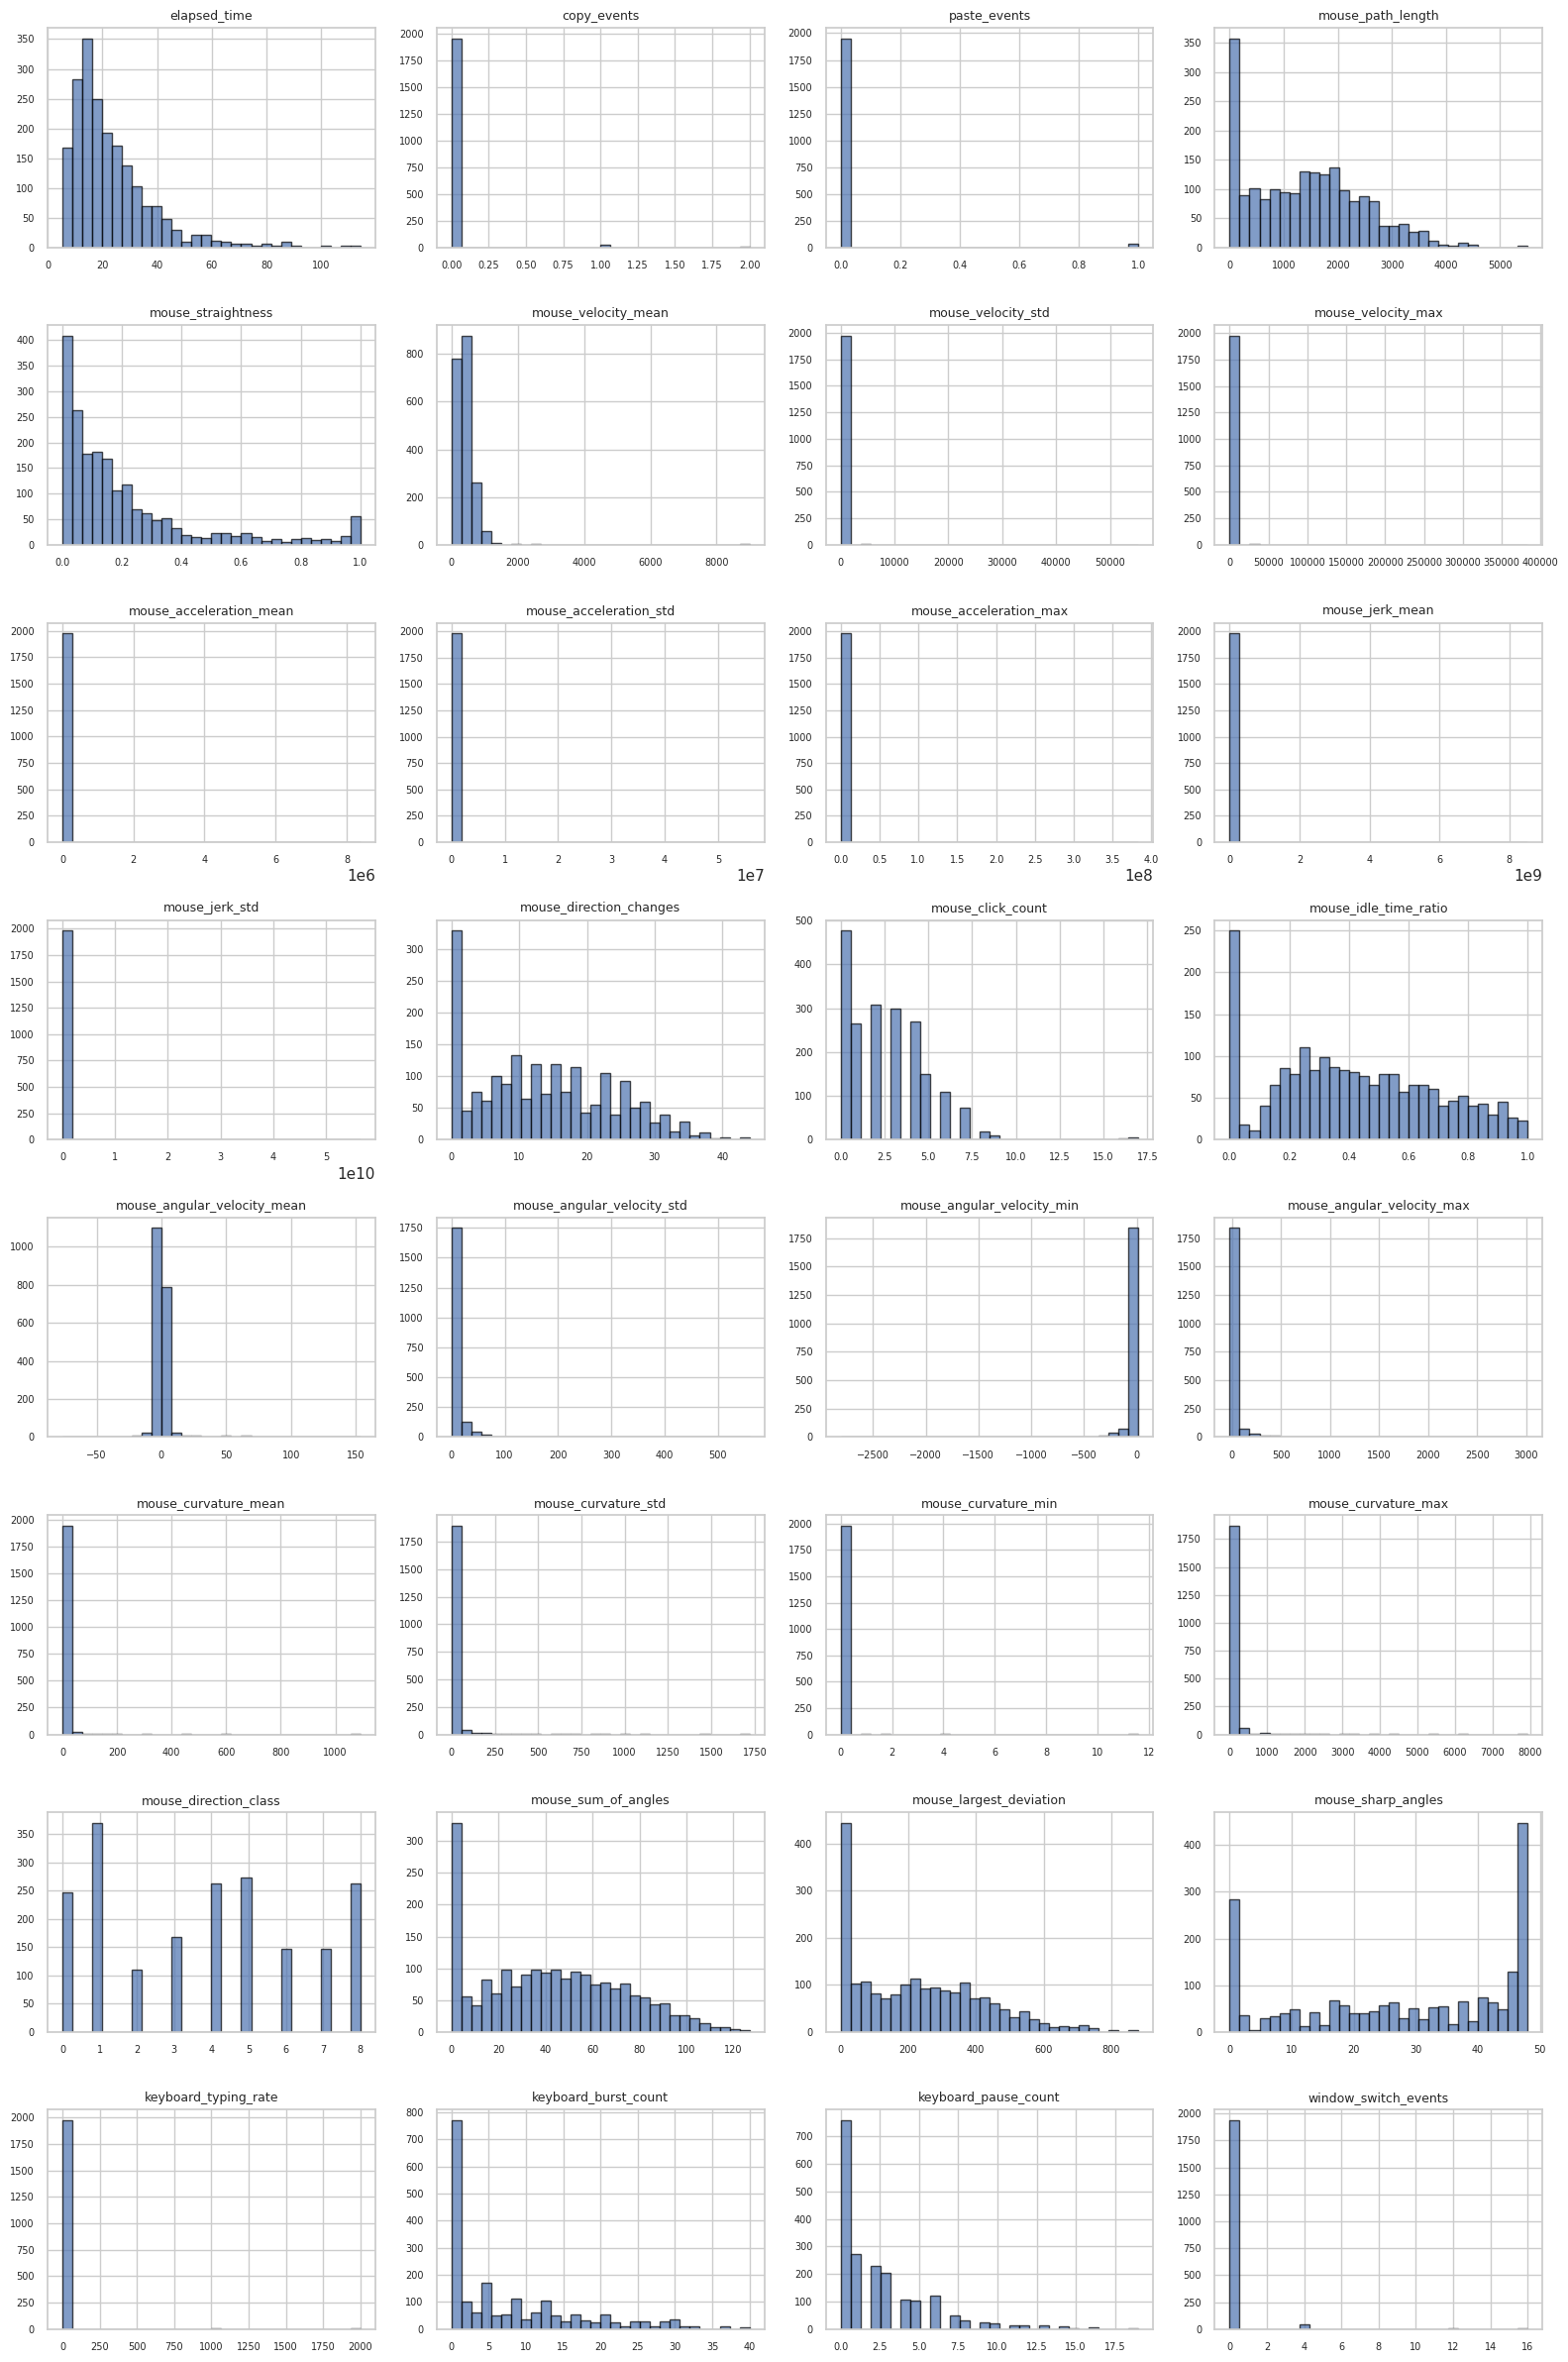

Note: Sparse features (e.g. copy_events, window_switch_events) are normal.
They are valuable discriminators for anomaly detection — not noise.


In [6]:
# ============================================================
# EDA: Feature Distributions (Train Normal Only)
# ============================================================
n_features = len(feature_names_viz)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(feature_names_viz):
    if i >= len(axes):
        break
    vals = X_train_viz[feat].dropna()
    axes[i].hist(vals, bins=30, alpha=0.7, edgecolor="black")
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(EDA_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Note: Sparse features (e.g. copy_events, window_switch_events) are normal.")
print("They are valuable discriminators for anomaly detection — not noise.")

=== Highly Correlated Pairs (|r| > 0.85) ===
Found 28 pairs



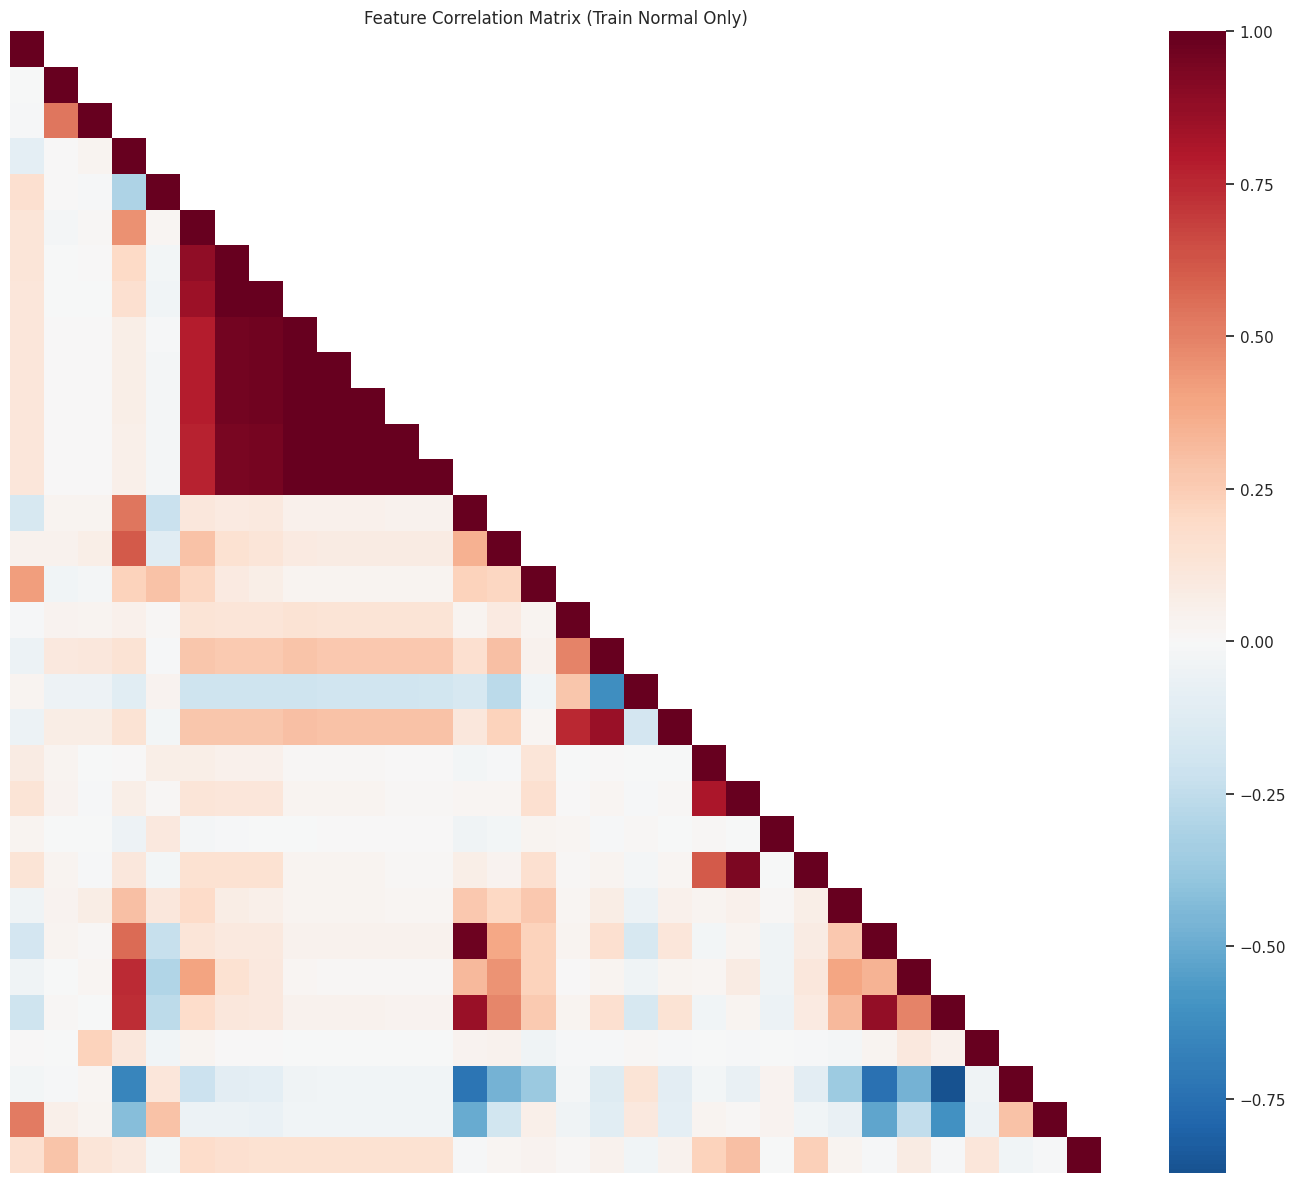

In [7]:
# ============================================================
# EDA: Correlation Analysis with Tiered Classification
# ============================================================
corr = X_train_viz.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

pairs = find_correlated_pairs(X_train_viz, threshold=config.high_corr_threshold)

print(f"=== Highly Correlated Pairs (|r| > {config.high_corr_threshold}) ===")
print(f"Found {len(pairs)} pairs\n")

pair_classifications = []
for feat1, feat2, r_val in sorted(pairs, key=lambda x: -abs(x[2])):
    tier = classify_correlation_pair(feat1, feat2)
    pair_classifications.append({
        "feature_1": feat1,
        "feature_2": feat2,
        "correlation": r_val,
        "tier": tier,
    })

df_pairs = pd.DataFrame(pair_classifications)
if len(df_pairs):
    df_pairs

# Correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr, mask=mask, cmap="RdBu_r", center=0,
    xticklabels=False, yticklabels=False,
)
plt.title("Feature Correlation Matrix (Train Normal Only)")
plt.tight_layout()
plt.savefig(EDA_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ============================================================
# EDA: Feature Summary & Keep/Drop Decisions
# ============================================================
fs = feature_summary(X_train_raw, corr_threshold=config.high_corr_threshold)

n_keep = (fs["decision"] == "KEEP").sum()
n_drop = (fs["decision"] == "DROP").sum()
print("=== Feature Summary & Decisions ===")
print(f"Total features: {len(fs)}")
print(f"Features to KEEP: {n_keep}")
print(f"Features to DROP: {n_drop}")
print()

dropped = fs[fs["decision"] == "DROP"]
if len(dropped):
    print("Dropped features:")
    dropped[["feature", "zero_variance", "tier1_redundant"]]

kept = fs[fs["decision"] == "KEEP"]
print(f"\nKept features ({len(kept)}):")
for feat in kept["feature"].tolist():
    print(f"  - {feat}")

=== Feature Summary & Decisions ===
Total features: 32
Features to KEEP: 25
Features to DROP: 7

Dropped features:

Kept features (25):
  - elapsed_time
  - copy_events
  - paste_events
  - mouse_path_length
  - mouse_straightness
  - mouse_velocity_mean
  - mouse_acceleration_mean
  - mouse_jerk_mean
  - mouse_direction_changes
  - mouse_click_count
  - mouse_idle_time_ratio
  - mouse_angular_velocity_mean
  - mouse_angular_velocity_std
  - mouse_angular_velocity_min
  - mouse_curvature_mean
  - mouse_curvature_std
  - mouse_curvature_min
  - mouse_direction_class
  - mouse_sum_of_angles
  - mouse_largest_deviation
  - mouse_sharp_angles
  - keyboard_typing_rate
  - keyboard_burst_count
  - keyboard_pause_count
  - window_switch_events
